In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.kernel_ridge import KernelRidge

from utils.RegressionOrdinalizer import RegressionOrdinalizer

import pathlib

# Identify biggest most influential variables on reviews

In [2]:
behavior=pathlib.Path("utils/shopping_behavior_updated.csv")
df=pd.read_csv(behavior)

In [3]:
mymap={'Yes':1,'No':0}
for col in ['Subscription Status', 'Discount Applied','Promo Code Used']:
    df[col]=df[col].map(mymap).astype('object')
def freq_factor(x):
    if x=='Every 3 Months': return 365/4
    if x=='Annually': return 365/1
    if x=='Quarterly': return 365/4
    if x=='Monthly': return 365/12
    if x=='Bi-Weekly': return 7/2
    if x=='Fortnightly': return 14
    if x=='Weekly': return 7
df['Total Days of Patronage']=(df['Frequency of Purchases'].map(freq_factor)*df['Previous Purchases']).astype(int)

In [4]:
from utils.BinnerClass import Bin
bin=Bin()
bin2=Bin()
#bin numeric columns
bin.relational_binner(df,max_cat_to_numeric_p=0.05,min_coeff=0.6,original_value_count_threashold=5,numeric_columns=None,categoric_columns=None)
for k, v in bin.numeric_target_column_minimums.items():
    df[f"{k}_binned"]=bin.binner(df[k],v)
    df[f"{k}_binned"]=df[f"{k}_binned"].astype('object')
bin2.relational_binner(df,max_cat_to_numeric_p=0.05,min_coeff=0.6,original_value_count_threashold=5,numeric_columns=['Age'],categoric_columns=None)
for k, v in bin2.numeric_target_column_minimums.items():
    df[f"{k}_binned"]=bin2.binner(df[k],v)
    df[f"{k}_binned"]=df[f"{k}_binned"].astype('object')

In [5]:
df.dtypes

Customer ID                         int64
Age                                 int64
Gender                             object
Item Purchased                     object
Category                           object
Purchase Amount (USD)               int64
Location                           object
Size                               object
Color                              object
Season                             object
Review Rating                     float64
Subscription Status                object
Shipping Type                      object
Discount Applied                   object
Promo Code Used                    object
Previous Purchases                  int64
Payment Method                     object
Frequency of Purchases             object
Total Days of Patronage             int64
Customer ID_binned                 object
Previous Purchases_binned          object
Purchase Amount (USD)_binned       object
Review Rating_binned               object
Total Days of Patronage_binned    

In [6]:
df.head(2)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,...,Previous Purchases,Payment Method,Frequency of Purchases,Total Days of Patronage,Customer ID_binned,Previous Purchases_binned,Purchase Amount (USD)_binned,Review Rating_binned,Total Days of Patronage_binned,Age_binned
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,...,14,Venmo,Fortnightly,196,1,1,2,1,1,3
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,...,2,Cash,Fortnightly,28,1,1,3,1,1,1


In [7]:
df['Review Rating'].value_counts()

Review Rating
3.4    182
4.0    181
4.6    174
4.2    171
2.9    170
4.9    166
3.9    163
3.0    162
2.6    159
4.4    158
3.1    157
3.5    156
3.7    156
2.7    154
3.3    152
3.2    152
3.6    149
4.1    148
4.7    148
4.3    147
4.8    144
3.8    142
4.5    139
2.8    136
5.0     68
2.5     66
Name: count, dtype: int64

In [8]:
regAna=RegressionOrdinalizer()
df=regAna.create_ordinalized_columns(df, 'Review Rating', feature_columns=None, center=None, rank=False, mode_trunc=['decimal',2,10])

In [9]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,...,Discount Applied_Ordinalized,Promo Code Used_Ordinalized,Payment Method_Ordinalized,Frequency of Purchases_Ordinalized,Customer ID_binned_Ordinalized,Previous Purchases_binned_Ordinalized,Purchase Amount (USD)_binned_Ordinalized,Review Rating_binned_Ordinalized,Total Days of Patronage_binned_Ordinalized,Age_binned_Ordinalized
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,...,3.739654,3.739654,3.751735,3.755166,3.747436,3.740578,3.674648,2.829382,3.8,3.732231
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,...,3.739654,3.739654,3.750448,3.755166,3.747436,3.740578,3.780203,2.829382,3.8,3.770449
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,...,3.739654,3.739654,3.782861,3.759555,3.747436,3.742008,3.780203,2.829382,3.8,3.747293
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,...,3.739654,3.739654,3.749631,3.759555,3.747436,3.767494,3.780061,3.449208,3.8,3.770449
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,...,3.739654,3.739654,3.749631,3.755944,3.747436,3.742008,3.674648,2.829382,3.7,3.747293


In [10]:
df.dtypes

Customer ID                                     int64
Age                                             int64
Gender                                         object
Item Purchased                                 object
Category                                       object
Purchase Amount (USD)                           int64
Location                                       object
Size                                           object
Color                                          object
Season                                         object
Review Rating                                 float64
Subscription Status                            object
Shipping Type                                  object
Discount Applied                               object
Promo Code Used                                object
Previous Purchases                              int64
Payment Method                                 object
Frequency of Purchases                         object
Total Days of Patronage     

In [11]:
regression_df=df[['Age', 'Purchase Amount (USD)', 'Review Rating', 'Subscription Status', 'Discount Applied', 'Promo Code Used', 'Previous Purchases',
                  'Total Days of Patronage_binned',
       'Previous Purchases_binned', 'Purchase Amount (USD)_binned',
       'Review Rating_binned', 'Age_binned', 'Gender_Ordinalized',
       'Item Purchased_Ordinalized', 'Category_Ordinalized',
       'Location_Ordinalized', 'Size_Ordinalized', 'Color_Ordinalized',
       'Season_Ordinalized', 'Subscription Status_Ordinalized',
       'Shipping Type_Ordinalized', 'Discount Applied_Ordinalized',
       'Promo Code Used_Ordinalized', 'Payment Method_Ordinalized',
       'Frequency of Purchases_Ordinalized', 'Customer ID_binned_Ordinalized',
       'Purchase Amount (USD)_binned_Ordinalized',
       'Review Rating_binned_Ordinalized',
       'Previous Purchases_binned_Ordinalized', 'Age_binned_Ordinalized']]
del df

In [12]:
regression_df.head()

,Age,Purchase Amount (USD),Review Rating,Subscription Status,Discount Applied,Promo Code Used,Previous Purchases,Total Days of Patronage_binned,Previous Purchases_binned,Purchase Amount (USD)_binned,...,Shipping Type_Ordinalized,Discount Applied_Ordinalized,Promo Code Used_Ordinalized,Payment Method_Ordinalized,Frequency of Purchases_Ordinalized,Customer ID_binned_Ordinalized,Purchase Amount (USD)_binned_Ordinalized,Review Rating_binned_Ordinalized,Previous Purchases_binned_Ordinalized,Age_binned_Ordinalized
0,55,53,3.1,1,1,1,14,1,1,2,...,3.776935,3.739654,3.739654,3.751735,3.755166,3.747436,3.674648,2.829382,3.740578,3.732231
1,19,64,3.1,1,1,1,2,1,1,3,...,3.776935,3.739654,3.739654,3.750448,3.755166,3.747436,3.780203,2.829382,3.740578,3.770449
2,50,73,3.1,1,1,1,23,1,2,3,...,3.717926,3.739654,3.739654,3.782861,3.759555,3.747436,3.780203,2.829382,3.742008,3.747293
3,21,90,3.5,1,1,1,49,1,3,4,...,3.720833,3.739654,3.739654,3.749631,3.759555,3.747436,3.780061,3.449208,3.767494,3.770449
4,45,49,2.7,1,1,1,31,2,2,2,...,3.717926,3.739654,3.739654,3.749631,3.755944,3.747436,3.674648,2.829382,3.742008,3.747293


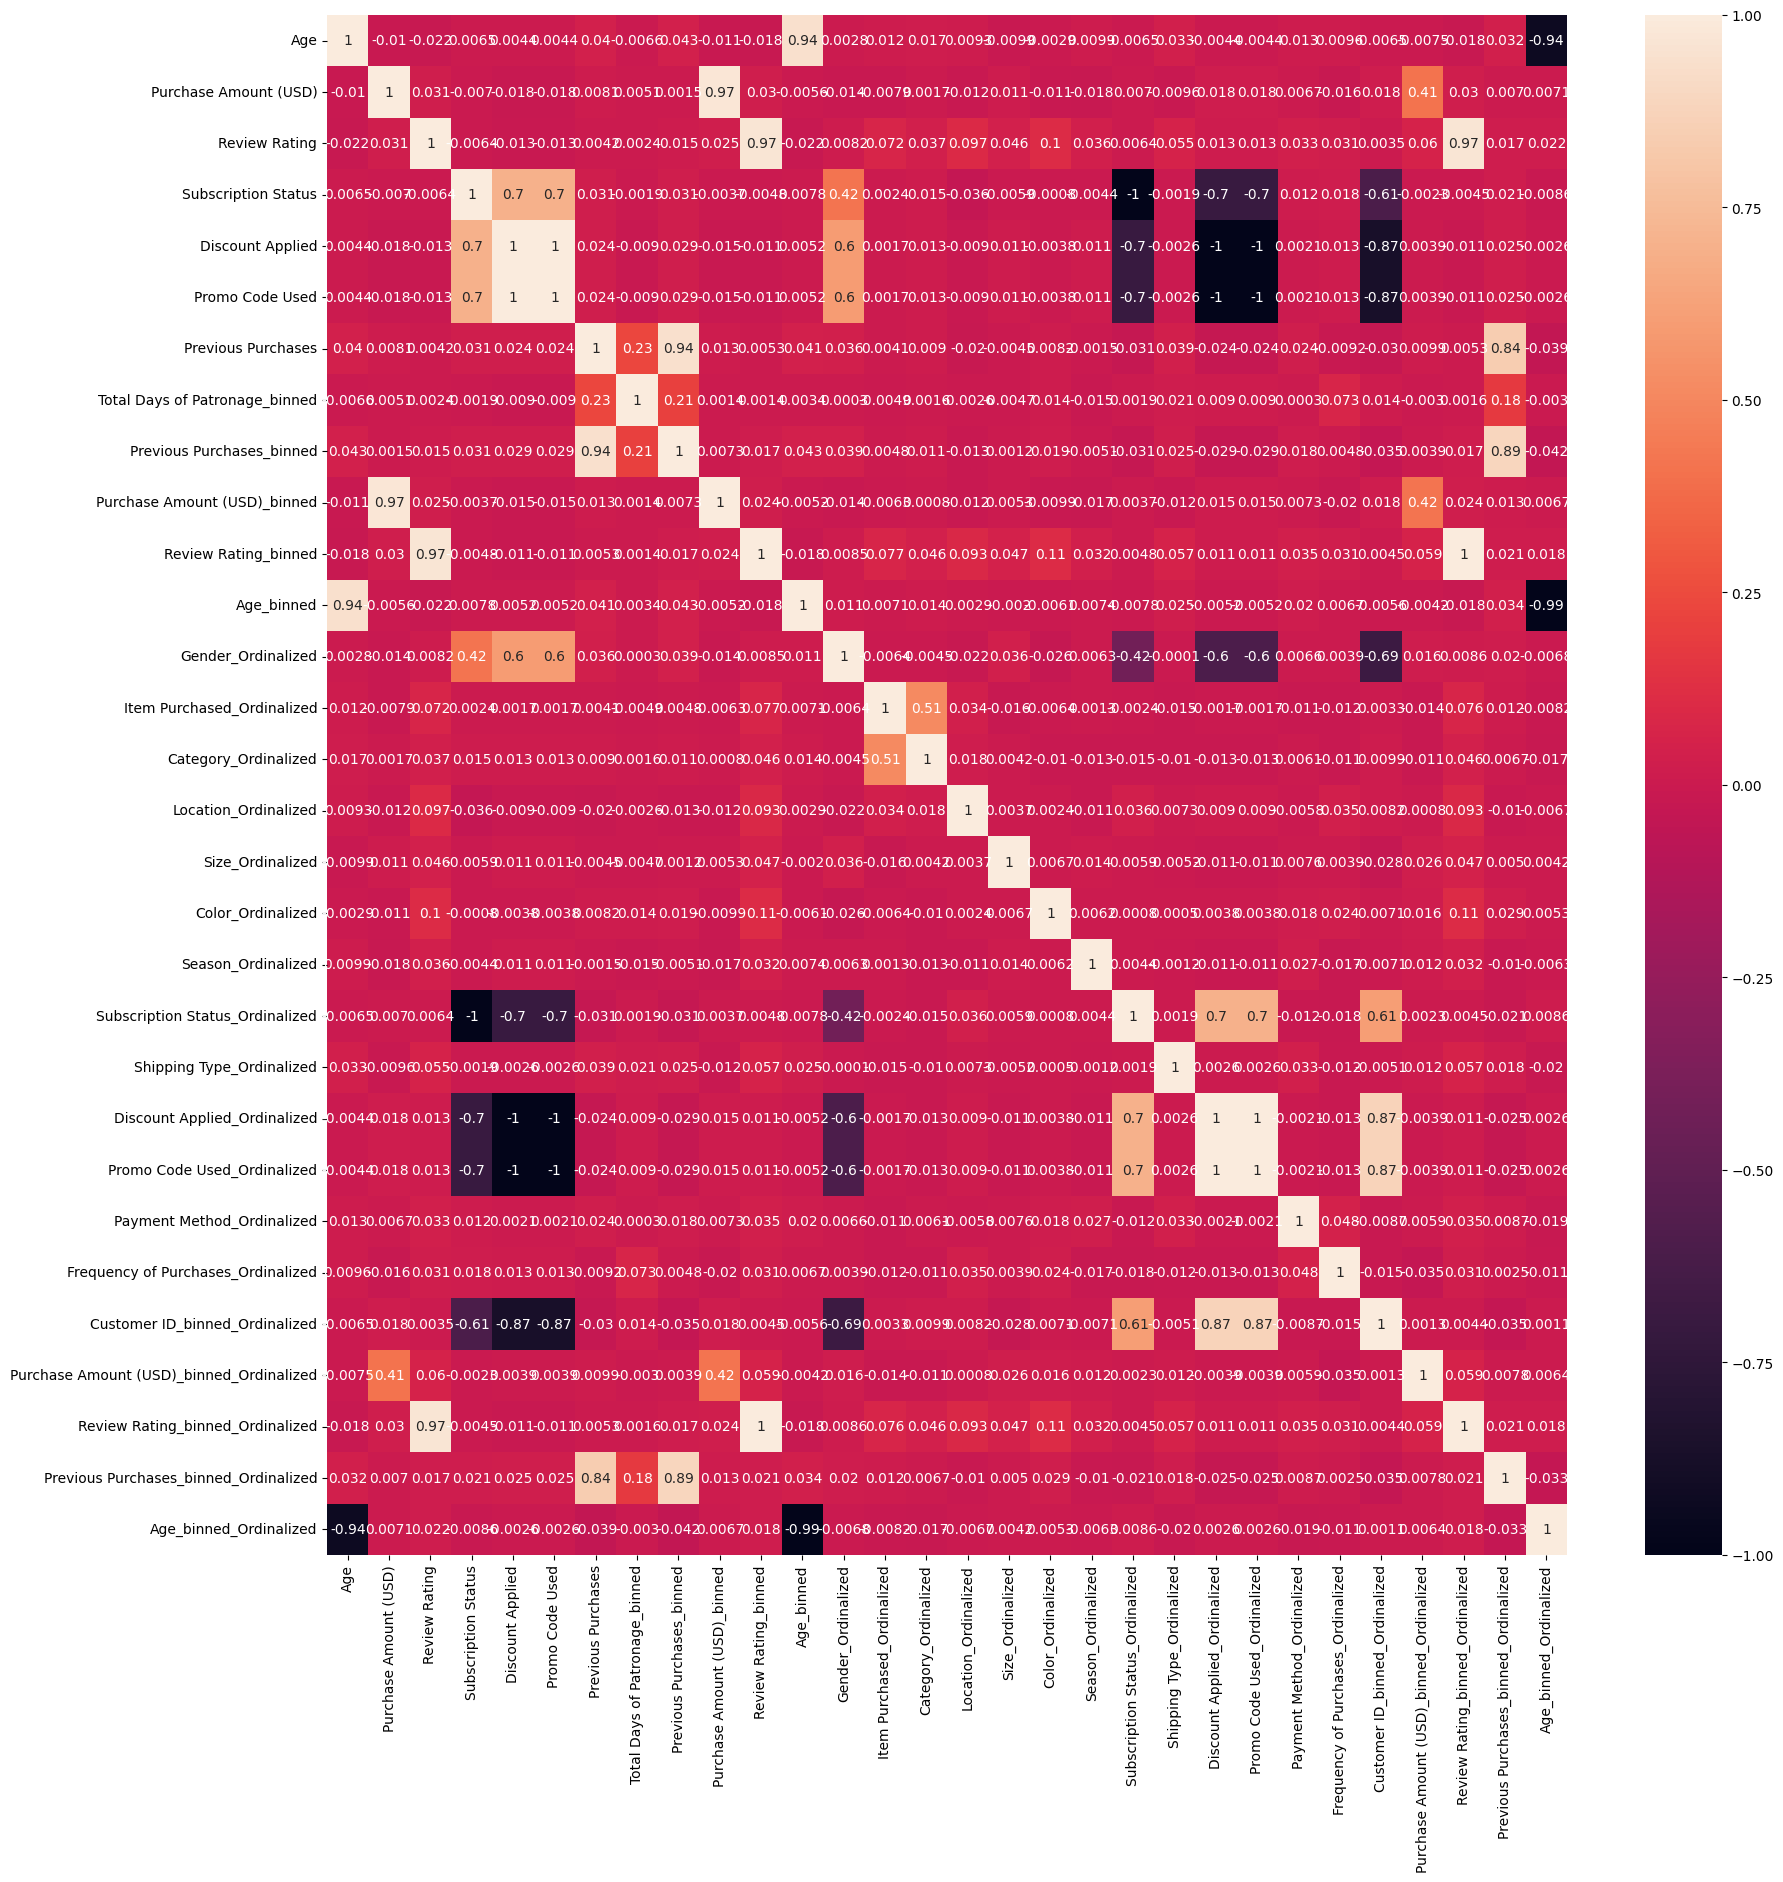

In [13]:
plt.figure(figsize=(20,20))
sns.heatmap(round(regression_df.corr(),4),annot=True)
plt.show()

The heatmap above indicates that the variable most correlated to "Review Rating" is Color. However, the correlation is week. It is 0.1 and 0.11 for "Review Rating_binned"


<Figure size 700x700 with 0 Axes>

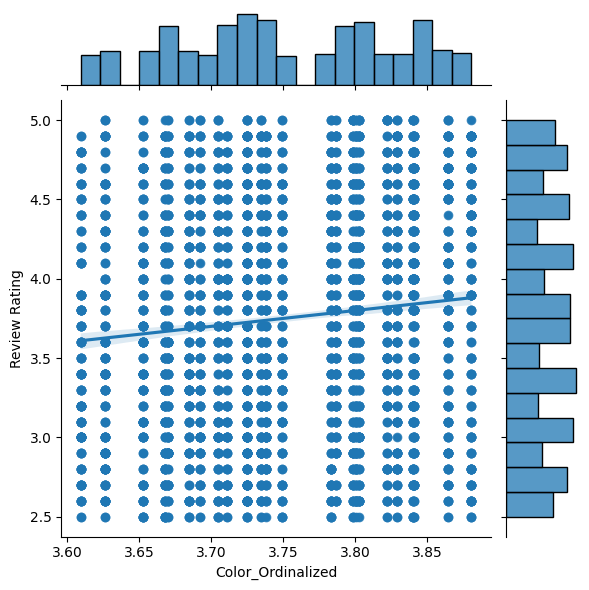

In [14]:
plt.figure(figsize=(7,7))
sns.jointplot(regression_df,x='Color_Ordinalized',y='Review Rating')
sns.regplot(regression_df,x='Color_Ordinalized',y='Review Rating')
plt.show()

In [15]:
y=regression_df['Review Rating']
X=regression_df.drop(columns=['Review Rating', 'Review Rating_binned_Ordinalized', 'Review Rating_binned' ])

Xtrain,Xtest,ytrain,ytest = train_test_split(X,y,test_size=0.2,random_state=42,shuffle=True)

scaler = StandardScaler()

Xtrain_scaled = scaler.fit_transform(Xtrain)
Xtest_scaled = scaler.transform(Xtest)



In [16]:
# a function to evaluate model regularization
def model_evaluator(Xtrain_scaled,Xtest_scaled,ytrain,ytest,model_,params):
    """
    """
    model=model_
    model.fit(Xtrain_scaled,ytrain)
    train_r2 = model.score(Xtrain_scaled,ytrain)
    test_r2  = model.score(Xtest_scaled,ytest)
    return params, {'train':train_r2,'test':test_r2}

examine models

In [17]:
for alpha in [0.0001,10,350,439,550]:
    res=model_evaluator(Xtrain_scaled,Xtest_scaled,ytrain,ytest,Ridge(alpha=alpha),{'alpha':alpha})
    print(res)

({'alpha': 0.0001}, {'train': 0.0405410846038482, 'test': 0.028262799023738072})
({'alpha': 10}, {'train': 0.0405264713870187, 'test': 0.028511657690388104})
({'alpha': 350}, {'train': 0.0391834716912105, 'test': 0.02990390028249912})
({'alpha': 439}, {'train': 0.03888062951924853, 'test': 0.029928506648051023})
({'alpha': 550}, {'train': 0.03850273120580294, 'test': 0.02989727640166895})


In [18]:
for alpha in [0.001,0.01,0.01,.1]:
    res=model_evaluator(Xtrain_scaled,Xtest_scaled,ytrain,ytest,Lasso(alpha=alpha),{'alpha':alpha})
    print(res)

({'alpha': 0.001}, {'train': 0.040166960835646415, 'test': 0.02967414430259052})
({'alpha': 0.01}, {'train': 0.03633005505053, 'test': 0.029919258735889298})
({'alpha': 0.01}, {'train': 0.03633005505053, 'test': 0.029919258735889298})
({'alpha': 0.1}, {'train': 0.0, 'test': -2.405711991104731e-05})


In [19]:
for alpha in [0.001,0.01,0.01,.1,1]:
    for ratio in [.7,.9]:
        res=model_evaluator(Xtrain_scaled,Xtest_scaled,ytrain,ytest,ElasticNet(alpha=alpha,l1_ratio=ratio),{'alpha':alpha,'l1_ratio':ratio})
        print(res)

({'alpha': 0.001, 'l1_ratio': 0.7}, {'train': 0.04033548434887513, 'test': 0.02942452997065892})
({'alpha': 0.001, 'l1_ratio': 0.9}, {'train': 0.0402296997446383, 'test': 0.029597010952801317})
({'alpha': 0.01, 'l1_ratio': 0.7}, {'train': 0.0374176768244866, 'test': 0.029679592028798663})
({'alpha': 0.01, 'l1_ratio': 0.9}, {'train': 0.03673202022530386, 'test': 0.029881482334191523})
({'alpha': 0.01, 'l1_ratio': 0.7}, {'train': 0.0374176768244866, 'test': 0.029679592028798663})
({'alpha': 0.01, 'l1_ratio': 0.9}, {'train': 0.03673202022530386, 'test': 0.029881482334191523})
({'alpha': 0.1, 'l1_ratio': 0.7}, {'train': 0.0007399312512467171, 'test': 0.0007630852110243058})
({'alpha': 0.1, 'l1_ratio': 0.9}, {'train': 0.0, 'test': -2.405711991104731e-05})
({'alpha': 1, 'l1_ratio': 0.7}, {'train': 0.0, 'test': -2.405711991104731e-05})
({'alpha': 1, 'l1_ratio': 0.9}, {'train': 0.0, 'test': -2.405711991104731e-05})


In [20]:
for min_samples_leaf in range(5,13):
    res=model_evaluator(Xtrain_scaled,Xtest_scaled,ytrain,ytest,RandomForestRegressor(max_depth=3,min_samples_leaf=min_samples_leaf),{'max_depth':3,'min_samples_leaf':min_samples_leaf})
    print(res)

({'max_depth': 3, 'min_samples_leaf': 5}, {'train': 0.04456629580066673, 'test': 0.020878813855496503})
({'max_depth': 3, 'min_samples_leaf': 6}, {'train': 0.04442794057167154, 'test': 0.021997354580694295})
({'max_depth': 3, 'min_samples_leaf': 7}, {'train': 0.044580134091507184, 'test': 0.020181000942973593})
({'max_depth': 3, 'min_samples_leaf': 8}, {'train': 0.04427412697915012, 'test': 0.020523566157503947})
({'max_depth': 3, 'min_samples_leaf': 9}, {'train': 0.045331575048961126, 'test': 0.02225613422176198})
({'max_depth': 3, 'min_samples_leaf': 10}, {'train': 0.044085275782850486, 'test': 0.021962531699890375})
({'max_depth': 3, 'min_samples_leaf': 11}, {'train': 0.044322459890274724, 'test': 0.020642221494001967})
({'max_depth': 3, 'min_samples_leaf': 12}, {'train': 0.04440847183447605, 'test': 0.022441465906080094})


None of the models performed well.   The best was Ridge regression with alpha = 439

In [21]:
regression=Ridge(alpha=439)
regression.fit(Xtrain_scaled,ytrain)


,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",439
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


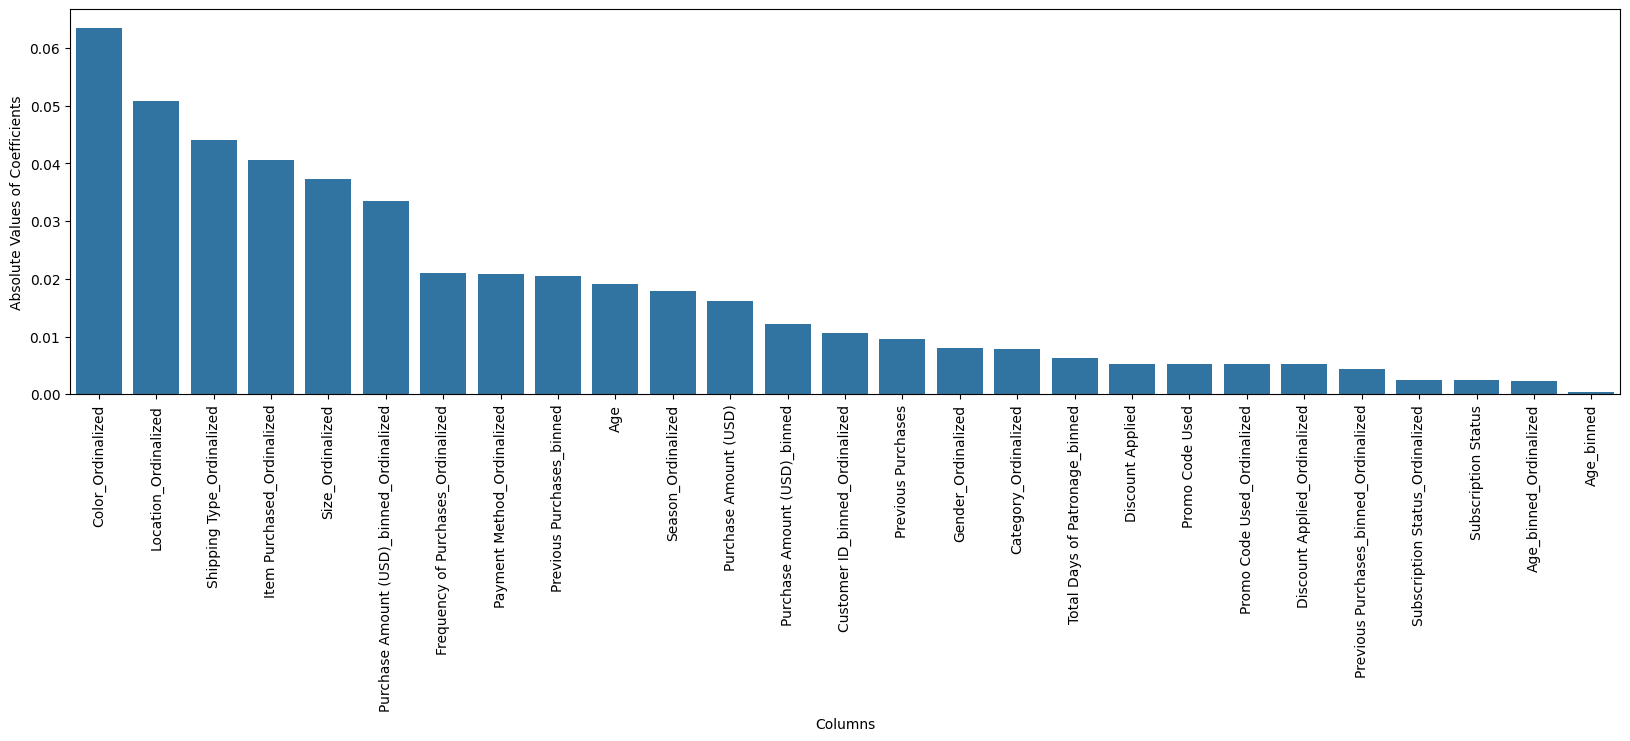

In [23]:
plt.figure(figsize=(20,5))
coeff_df=pd.DataFrame({'Coefficients':list(regression.coef_),'Columns':list(Xtrain.columns)})
coeff_df['Coefficients'] = abs(coeff_df['Coefficients'])
coeff_df=coeff_df.sort_values(by="Coefficients",ascending=False)
sns.barplot(x=coeff_df['Columns'],y=coeff_df['Coefficients'])
plt.ylabel('Absolute Values of Coefficients')
plt.xticks(rotation=90)
plt.show()